
# 생성형 AI 서비스 개발의 이해 (LangChain) — 개인 변경 실습

## 제조 설비 점검 AI 어시스턴트

- **목적**: Day1~Day3에서 학습한 Structured Output, Memory, Tool, Reliability, RAG, Agent/LangGraph 개념을 하나의 개인 시나리오로 통합
- **시나리오**: 설비 이상 문의가 들어오면 문의를 구조화하고, 필요 시 센서 상태 조회 → 정비 매뉴얼 RAG → 담당자 알림까지 Agent가 동적으로 선택

### 전체 흐름

`사용자 문의 → Agent → 분류 / 센서 조회 / RAG / 알림 Tool 선택 → 중간 결과 확인 → 추가 Tool 판단 → 최종 답변`




## 0. 실행 환경

프로젝트의 `.env`에 아래 값을 설정합니다.

```text
OPENAI_API_KEY=...
LANGSMITH_API_KEY=...
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=langchain-equipment-maintenance
```

필요 패키지 예시:

```bash
python -m pip install langchain langchain-openai langchain-chroma langchain-text-splitters langgraph python-dotenv pydantic gradio
```


In [1]:

from __future__ import annotations

import json
import os
import uuid
from typing import Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

print("OPENAI_API_KEY:", "설정됨" if os.getenv("OPENAI_API_KEY") else "미설정")
print("LANGSMITH_TRACING:", os.getenv("LANGSMITH_TRACING", "false"))
print("LANGSMITH_PROJECT:", os.getenv("LANGSMITH_PROJECT", "(기본값)"))


OPENAI_API_KEY: 설정됨
LANGSMITH_TRACING: true
LANGSMITH_PROJECT: langchain-pattern



## 1. Day1 — Structured Output

설비 문의를 단순 문자열로 받는 대신 아래 네 필드로 구조화합니다.

- `category`: 일반 문의 / 점검 요청 / 이상 의심 / 긴급
- `severity`: low / medium / high / critical
- `equipment_id`: 문의에 명시된 설비 ID
- `summary`: 문의 핵심 요약

이 결과는 이후 Agent가 센서 조회, RAG, 담당자 알림이 필요한지 판단할 때 사용할 수 있습니다.


In [2]:

def build_reliable_model(*, structured_output=None):
    """Leaf Chain용 안정성 모델.

    Structured Output 설정 후 retry/fallback을 적용한다.
    최상위 create_agent 모델에는 Runnable wrapper 대신 ChatOpenAI(max_retries=...)를 사용한다.
    """
    primary = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    backup = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    if structured_output is not None:
        primary = primary.with_structured_output(structured_output)
        backup = backup.with_structured_output(structured_output)

    primary = primary.with_retry(stop_after_attempt=2)
    backup = backup.with_retry(stop_after_attempt=2)
    return primary.with_fallbacks([backup])


class EquipmentInquiry(BaseModel):
    category: Literal["normal", "inspection", "anomaly", "emergency"] = Field(
        description="일반 문의=normal, 점검 요청=inspection, 이상 의심=anomaly, 즉시 대응 필요=emergency"
    )
    severity: Literal["low", "medium", "high", "critical"] = Field(
        description="수업용 업무 우선순위"
    )
    equipment_id: str | None = Field(
        default=None,
        description="문장에 명시된 설비 ID. 예: MOTOR-03, PUMP-02. 없으면 null",
    )
    summary: str = Field(description="문의 핵심을 한 문장으로 요약")


_classifier = None

def _get_classifier():
    global _classifier
    if _classifier is None:
        _classifier = build_reliable_model(structured_output=EquipmentInquiry)
    return _classifier


@tool
def classify_equipment_issue(description: str) -> str:
    """설비 이상 증상이나 점검 문의를 구조화하여 분류한다."""
    result: EquipmentInquiry = _get_classifier().invoke(description)
    return json.dumps(result.model_dump(), ensure_ascii=False)



## 2. Day2 — Tool

Agent가 외부 상태를 확인하거나 후속 행동을 할 수 있도록 Tool을 제공합니다.

- `get_sensor_status`: 가상 센서 DB 조회
- `notify_maintenance`: 정비 담당자 알림을 생성했다고 가정하는 데모 Tool

Tool을 실제로 사용할지, 어떤 순서로 사용할지는 Agent가 실행 중 판단합니다.


In [ ]:

_SENSOR_DB = {
    "MOTOR-03": {
        "status": "ALARM",
        "vibration_mm_s": 8.7,
        "bearing_temp_c": 88,
        "current_a": 14.8,
        "note": "진동과 베어링 온도가 데모 기준치를 초과한 상태",
    },
    "PUMP-02": {
        "status": "WARNING",
        "vibration_mm_s": 5.2,
        "bearing_temp_c": 74,
        "current_a": 11.1,
        "note": "진동이 평상시보다 높아 추세 확인이 필요한 상태",
    },
    "FAN-01": {
        "status": "NORMAL",
        "vibration_mm_s": 2.1,
        "bearing_temp_c": 51,
        "current_a": 7.4,
        "note": "가상 정상 범위",
    },
}


@tool
def get_sensor_status(equipment_id: str) -> str:
    """가상 설비 ID의 현재 센서 상태를 조회한다."""
    key = equipment_id.strip().upper()
    data = _SENSOR_DB.get(key)

    if data is None:
        return json.dumps(
            {
                "found": False,
                "equipment_id": key,
                "message": "등록된 데모 센서 데이터가 없습니다.",
            },
            ensure_ascii=False,
        )

    return json.dumps(
        {"found": True, "equipment_id": key, **data},
        ensure_ascii=False,
    )


@tool
def notify_maintenance(equipment_id: str, reason: str) -> str:
    """정비 담당자에게 알림을 보냈다고 가정하는 Tool."""
    key = equipment_id.strip().upper() if equipment_id else "UNKNOWN"
    return (
        f"[DEMO] 정비 담당자 알림 접수 완료 | 설비={key} | 사유={reason} | "
        "실제 외부 전송/설비 제어는 수행하지 않았습니다."
    )



## 3. Day3 — RAG

가상의 사내 정비 매뉴얼을 `Document → Chunk → Embedding → Chroma → Retriever` 흐름으로 구성합니다.

질문이 들어오면:

`질문 → Retriever → 관련 Document → format_docs → Prompt → LLM → 답변`

으로 동작하며, 문서에 없는 내용은 추측하지 않도록 제한합니다.


In [4]:

_MAINTENANCE_DOCS = [
    Document(
        page_content=(
            "[회전 설비 진동 점검 절차 - 데모] 진동 이상이 감지되면 설비 ID와 현재 센서 값을 먼저 확인한다. "
            "MOTOR-03 데모 기준에서는 진동 7.1 mm/s 이상을 ALARM 예시로 사용한다. "
            "베어링 체결 상태, 정렬, 윤활 상태를 순서대로 점검하고 임의 분해 작업은 하지 않는다."
        ),
        metadata={"source": "demo_rotating_equipment_manual", "topic": "vibration"},
    ),
    Document(
        page_content=(
            "[베어링 온도 상승 대응 - 데모] 베어링 온도가 데모 기준 80°C를 넘으면 고온 상태로 기록하고, "
            "진동·전류 값과 함께 확인한다. 고온과 높은 진동이 동시에 나타나면 정비 담당자 확인 대상으로 분류한다."
        ),
        metadata={"source": "demo_bearing_manual", "topic": "temperature"},
    ),
    Document(
        page_content=(
            "[펌프 점검 절차 - 데모] 펌프 진동 증가 시 흡입/토출 조건, 베어링 상태, 캐비테이션 가능성을 점검한다. "
            "WARNING 상태에서는 추세를 재확인하고 급격한 상승이나 추가 이상 신호가 있으면 담당자에게 에스컬레이션한다."
        ),
        metadata={"source": "demo_pump_manual", "topic": "pump"},
    ),
    Document(
        page_content=(
            "[정비 에스컬레이션 정책 - 데모] 분류 결과가 high 또는 critical이거나 센서 상태가 ALARM이면 "
            "정비 담당자 알림을 생성한다. 실제 작업 전에는 현장 안전 규정과 담당자의 승인을 우선한다."
        ),
        metadata={"source": "demo_escalation_policy", "topic": "escalation"},
    ),
    Document(
        page_content=(
            "[정상 설비 문의 - 데모] 현재 상태가 NORMAL이고 사용자가 일반 점검 주기나 사용 방법을 묻는 경우에는 "
            "불필요한 긴급 알림 없이 매뉴얼 근거만 안내한다."
        ),
        metadata={"source": "demo_general_policy", "topic": "normal"},
    ),
]


def format_docs(docs: list[Document]) -> str:
    """Retriever의 Document 리스트를 출처가 보이는 하나의 문자열로 변환."""
    return "\n\n---\n\n".join(
        f"[출처: {d.metadata.get('source', 'unknown')}]\n{d.page_content}"
        for d in docs
    )


_retriever = None
_rag_chain = None


def build_rag_components():
    global _retriever, _rag_chain

    if _retriever is not None and _rag_chain is not None:
        return _retriever, _rag_chain

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=450,
        chunk_overlap=60,
    )
    chunks = splitter.split_documents(_MAINTENANCE_DOCS)

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=OpenAIEmbeddings(model="text-embedding-3-small"),
        collection_name=f"equipment_maintenance_demo_{uuid.uuid4().hex[:8]}",
    )
    _retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

    prompt = ChatPromptTemplate.from_template(
        """너는 제조 설비 정비 문서를 안내하는 AI다.
아래 데모 문서에 근거해서만 답한다. 문서에 없는 사실은 추측하지 않는다.
실제 현장 작업은 안전 규정과 담당자 승인을 우선한다고 명시한다.

[검색 문서]
{context}

[질문]
{question}

간결하게 답하고 사용한 문서 출처 이름도 함께 알려줘."""
    )

    _rag_chain = (
        RunnableParallel(
            context=_retriever | format_docs,
            question=RunnablePassthrough(),
        )
        | prompt
        | build_reliable_model()
        | StrOutputParser()
    )

    return _retriever, _rag_chain


@tool
def search_maintenance_manual(query: str) -> str:
    """가상의 사내 정비 매뉴얼/정책을 RAG로 검색하여 근거 기반 답변을 생성한다."""
    _, rag_chain = build_rag_components()
    return rag_chain.invoke(query)



## 4. Day3 — Agent + LangGraph Memory

최상위 Agent에는 다음 4개 Tool을 제공합니다.

1. `classify_equipment_issue`
2. `get_sensor_status`
3. `search_maintenance_manual`
4. `notify_maintenance`

개발자는 **사용 가능한 Tool과 안전 규칙**을 정의하고, Agent는 실행 중 **어떤 Tool을 쓸지, 추가 Tool이 필요한지, 언제 종료할지**를 동적으로 판단합니다.

`InMemorySaver`와 `thread_id`를 사용하여 같은 세션의 대화 상태를 유지합니다.


In [10]:

def build_unified_agent():
    # 첫 질문 전에 RAG 임베딩을 준비한다.
    build_rag_components()

    agent_model = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0,
        max_retries=2,
    )

    system_prompt = """너는 제조 설비 점검 AI 어시스턴트다.
    모든 센서 값과 기준은 수업용 데모 데이터이며 실제 설비 조작을 수행하지 않는다.

    도구 사용 원칙:
    1. 사용자가 이상 소음/진동/고온/누유/정지 같은 증상을 말하면
    classify_equipment_issue로 먼저 구조화한다.

    2. 설비 ID가 있고 현재 상태 확인이 필요하면
    get_sensor_status를 사용한다.
    센서 값을 추측하지 않는다.

    3. classify_equipment_issue 결과가 anomaly/emergency이거나,
    get_sensor_status 결과가 WARNING/ALARM이면
    최종 조치를 안내하기 전에 반드시 search_maintenance_manual을 사용하여
    관련 정비 절차와 에스컬레이션 정책을 확인한다.

    4. 정비 매뉴얼 조회 결과와 센서 상태를 함께 확인한 뒤,
    severity가 high/critical이거나 센서 상태가 ALARM이면
    notify_maintenance를 사용해 데모 알림을 남긴다.

    5. 한 번에 여러 도구가 필요할 수 있다.
    도구 결과를 확인한 뒤 필요한 다음 도구를 스스로 판단한다.

    6. 충분한 근거가 모이면 반복을 끝내고,
    관찰된 사실과 권장 다음 단계를 구분하여 답한다.

    7. 실제 현장 작업은 안전 규정과 담당자 승인을 우선한다고 안내한다.
    """
    return create_agent(
        agent_model,
        tools=[
            classify_equipment_issue,
            get_sensor_status,
            search_maintenance_manual,
            notify_maintenance,
        ],
        system_prompt=system_prompt,
        checkpointer=InMemorySaver(),
    )


agent = build_unified_agent()
print("Agent 준비 완료")


Agent 준비 완료



## 5. 평가 시나리오 1 — 통합 Agent 흐름

### 입력

> MOTOR-03에서 평소보다 진동이 심하고 베어링 쪽이 뜨거운 것 같아. 현재 상태와 필요한 조치를 알려줘.

### 기대 관찰

Agent가 상황에 따라 아래 Tool을 선택합니다.

`분류 → 센서 조회 → 정비 매뉴얼 RAG → 필요 시 담당자 알림 → 최종 답변`

Tool 호출 순서는 LLM 판단에 따라 달라질 수 있으며, **중간 결과에 따라 다음 행동을 동적으로 정한다는 점**이 핵심입니다.


In [11]:

def run_and_report(agent, thread_id: str, question: str):
    """제출용 로그 스냅샷을 쉽게 남기기 위한 실행 함수."""
    result = agent.invoke(
        {"messages": [("user", question)]},
        config={"configurable": {"thread_id": thread_id}},
    )

    tool_calls = []
    for msg in result["messages"]:
        calls = getattr(msg, "tool_calls", None)
        if calls:
            tool_calls.extend(call["name"] for call in calls)

    print("[질문]")
    print(question)
    print("\n[실행된 Tool]")
    print(" → ".join(tool_calls) if tool_calls else "(Tool 호출 없음)")
    print("\n[최종 답변]")
    print(result["messages"][-1].content)

    return result


result_main = run_and_report(
    agent,
    "equipment-demo-a",
    "MOTOR-03에서 평소보다 진동이 심하고 베어링 쪽이 뜨거운 것 같아. 현재 상태와 필요한 조치를 알려줘.",
)


[질문]
MOTOR-03에서 평소보다 진동이 심하고 베어링 쪽이 뜨거운 것 같아. 현재 상태와 필요한 조치를 알려줘.

[실행된 Tool]
classify_equipment_issue → get_sensor_status → search_maintenance_manual → notify_maintenance

[최종 답변]
관찰된 사실:
- MOTOR-03에서 평소보다 진동이 심하고 베어링 쪽이 뜨거운 현상이 발생했습니다.
- 현재 MOTOR-03의 진동은 8.7 mm/s로 ALARM 상태이며, 베어링 온도는 88°C로 기준치를 초과했습니다.

권장 다음 단계:
- 정비 매뉴얼에 따르면, 진동과 베어링 온도가 동시에 이상 상태일 경우 정비 담당자에게 확인을 요청해야 합니다.
- 정비 담당자에게 알림을 보냈습니다. 

안전 규정과 담당자 승인을 우선적으로 고려하시기 바랍니다.



## 6. 평가 시나리오 2 — Memory 확인

같은 `thread_id`로 후속 질문을 보내어 이전 Turn의 설비 ID를 기억하는지 확인합니다.

1. 이전 질문에서 `MOTOR-03`을 명시
2. 후속 질문에서는 설비 ID를 다시 쓰지 않고 **“아까 그 설비”**라고 표현
3. Agent가 이전 대화의 `MOTOR-03` 맥락을 활용하는지 확인


In [12]:

result_memory = run_and_report(
    agent,
    "equipment-demo-a",  # 시나리오 1과 동일한 thread_id
    "아까 그 설비에서 가장 먼저 확인해야 할 항목만 다시 알려줘.",
)


[질문]
아까 그 설비에서 가장 먼저 확인해야 할 항목만 다시 알려줘.

[실행된 Tool]
classify_equipment_issue → get_sensor_status → search_maintenance_manual → notify_maintenance

[최종 답변]
MOTOR-03에서 가장 먼저 확인해야 할 항목은 다음과 같습니다:

1. **진동 상태**: 현재 진동이 8.7 mm/s로 ALARM 상태입니다.
2. **베어링 온도**: 현재 베어링 온도가 88°C로 기준치를 초과했습니다.

이 두 가지 항목이 동시에 이상 상태이므로, 정비 담당자에게 확인을 요청하는 것이 중요합니다.



## 7. 평가 시나리오 3 — RAG 단독 확인

### 입력

> 펌프 진동이 증가했을 때 사내 점검 절차가 어떻게 돼?

LangSmith에서는 `search_maintenance_manual` 내부의 다음 흐름을 확인할 수 있습니다.

`RunnableParallel → Retriever → format_docs → Prompt → Model → Parser`


In [13]:

result_rag = run_and_report(
    agent,
    "equipment-demo-b",
    "펌프 진동이 증가했을 때 사내 점검 절차가 어떻게 돼?",
)


[질문]
펌프 진동이 증가했을 때 사내 점검 절차가 어떻게 돼?

[실행된 Tool]
search_maintenance_manual

[최종 답변]
펌프 진동이 증가했을 때의 사내 점검 절차는 다음과 같습니다:

1. **흡입/토출 조건 점검**: 펌프의 흡입 및 토출 조건을 확인합니다.
2. **베어링 상태 점검**: 베어링의 상태를 점검하여 마모나 손상이 있는지 확인합니다.
3. **캐비테이션 가능성 점검**: 캐비테이션이 발생할 가능성을 점검합니다.

또한, 만약 센서 상태가 WARNING이라면, 진동 추세를 재확인하고 급격한 상승이나 추가 이상 신호가 발견되면 담당자에게 에스컬레이션해야 합니다.

안전 규정과 담당자 승인을 우선적으로 고려해야 합니다.



## 8. LangSmith Trace 캡처 


### 통합 시나리오
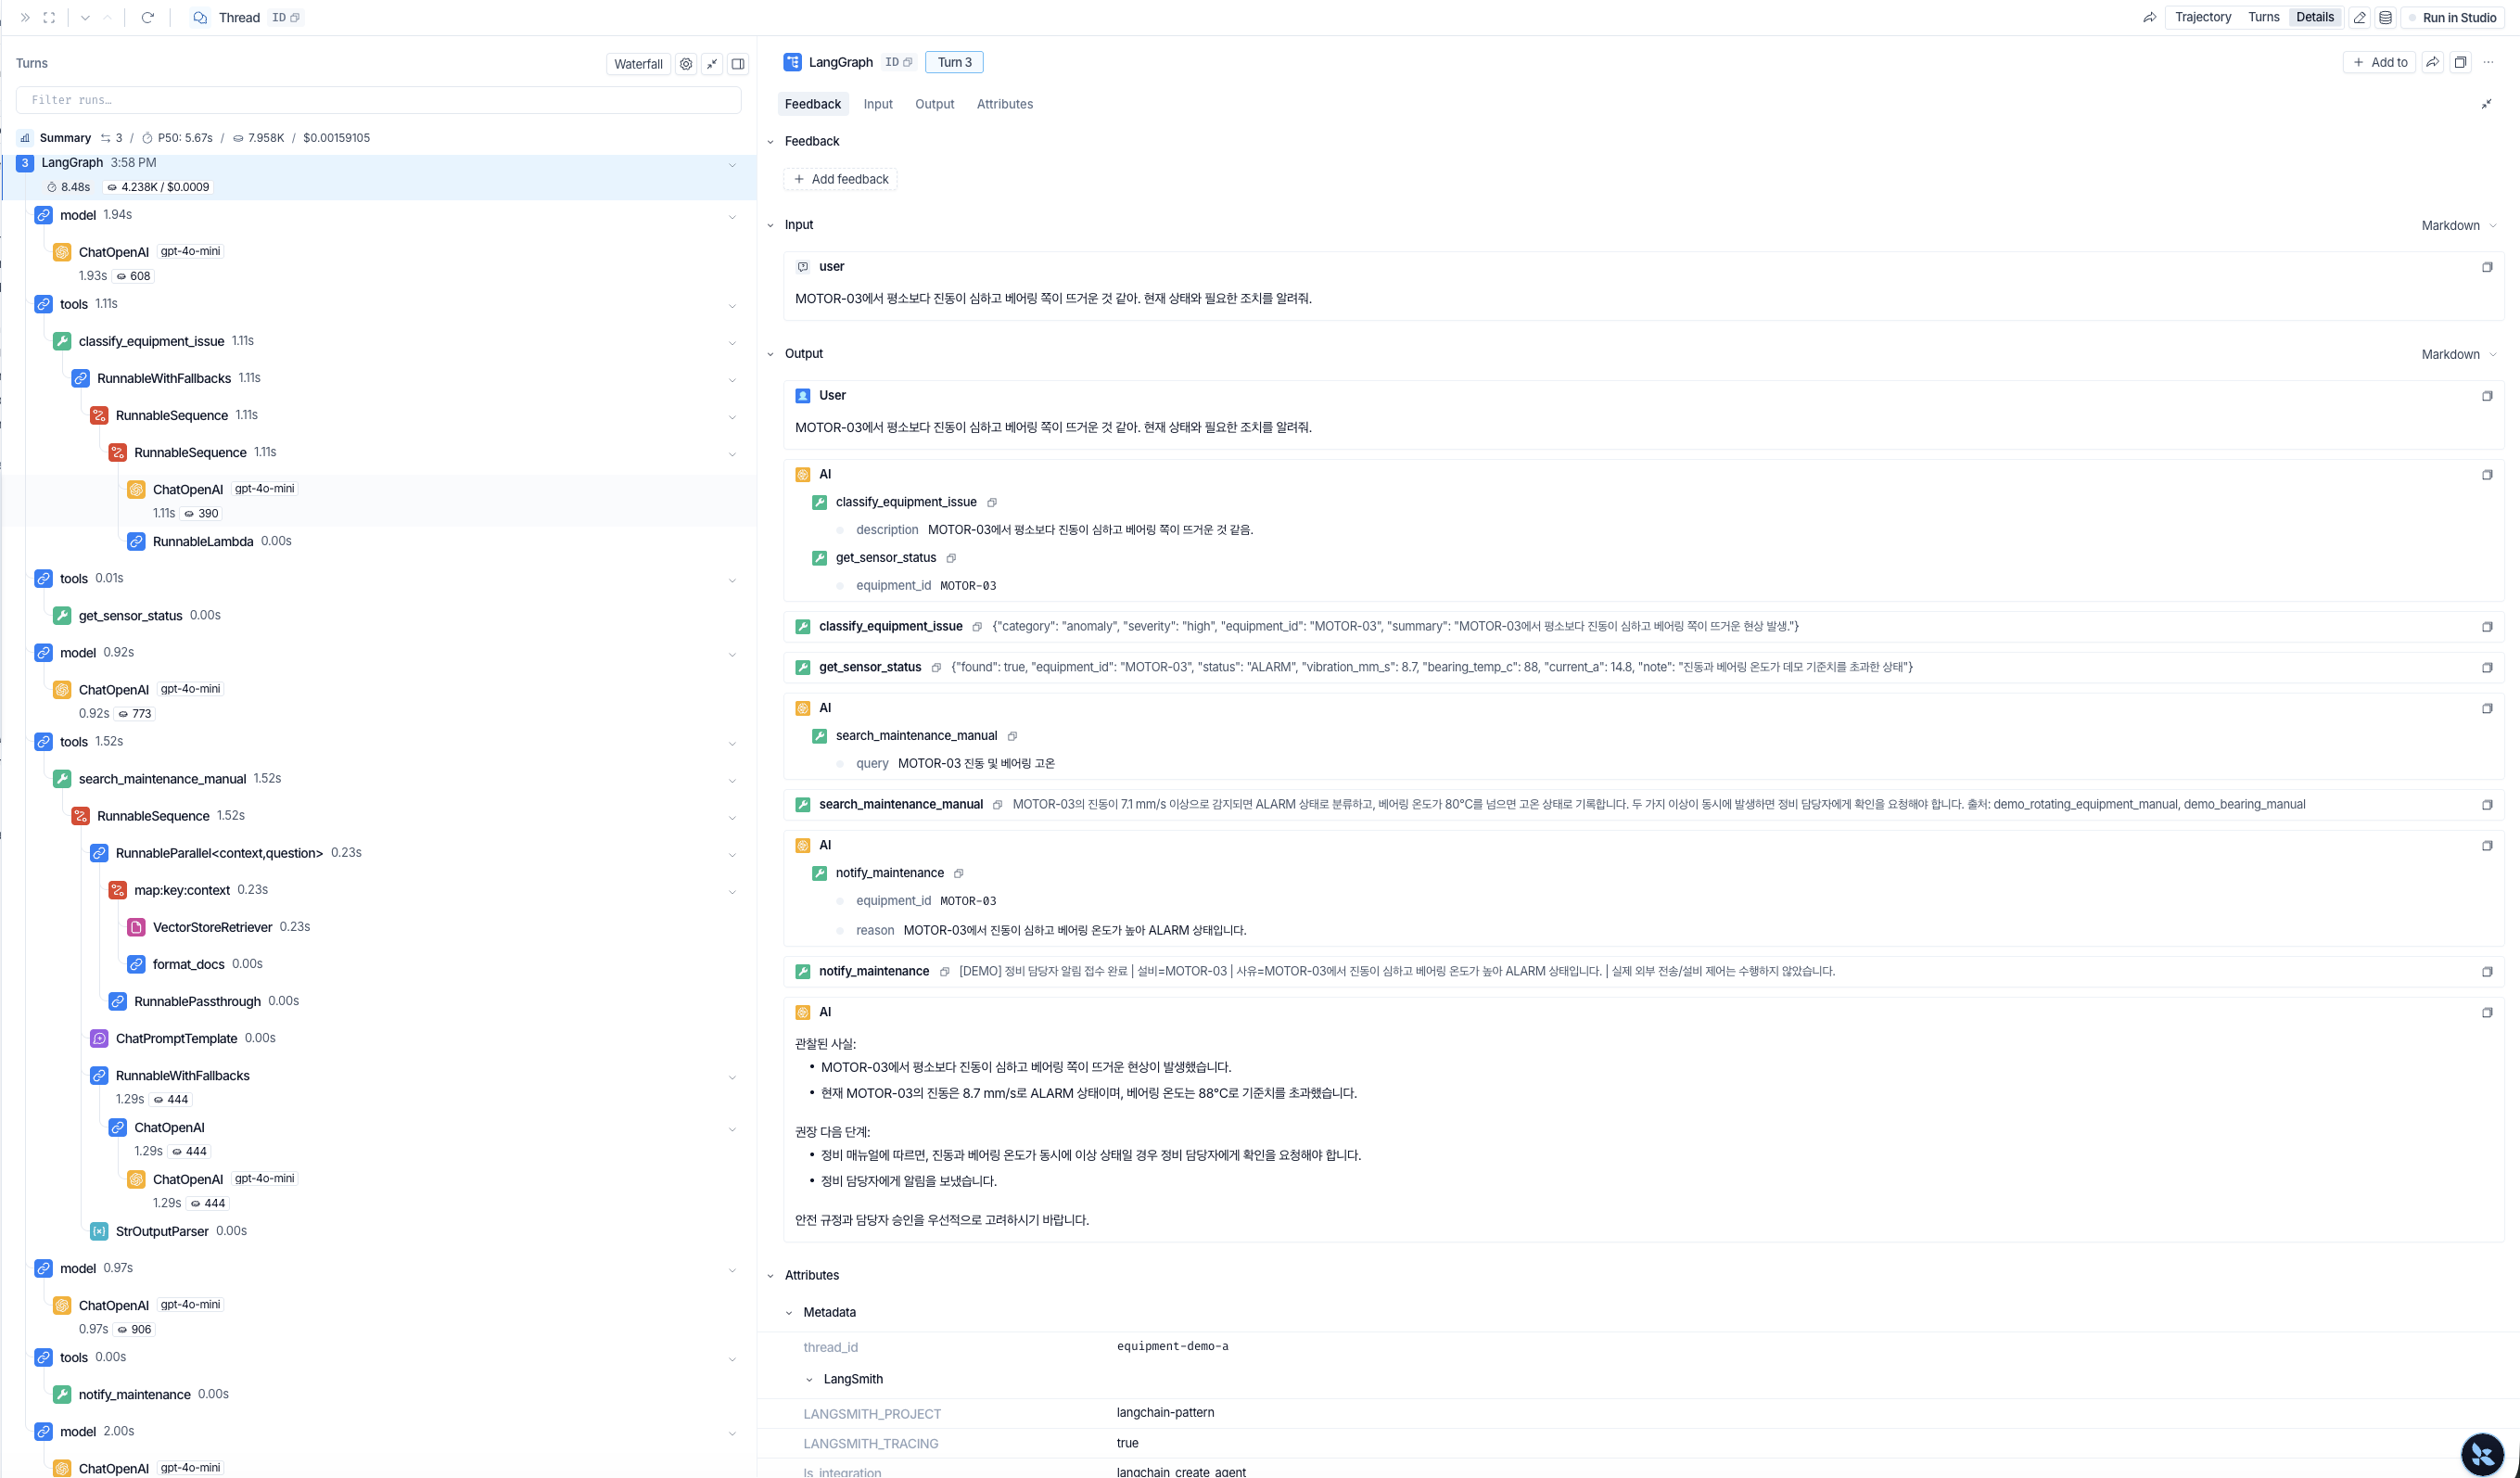

- 설비 이상 문의에 대해 Agent는 먼저 Structured Output 기반으로 문의를 anomaly/high로 분류하고, get_sensor_status Tool을 통해 MOTOR-03의 진동 및 베어링 온도가 데모 기준을 초과한 ALARM 상태임을 확인하였다. 이후 중간 결과를 바탕으로 search_maintenance_manual을 추가 호출하여 RAG를 통해 관련 정비 절차를 검색하였으며, 높은 위험도와 센서 상태를 종합한 뒤 notify_maintenance Tool을 호출해 정비 담당자에게 에스컬레이션하였다. 이를 통해 분류 → 상태 조회 → RAG 근거 확보 → 후속 행동이 고정된 순서가 아니라 Agent의 중간 판단에 따라 동적으로 이어지는 Agentic Workflow가 정상적으로 동작함을 확인하였다.

### Memory

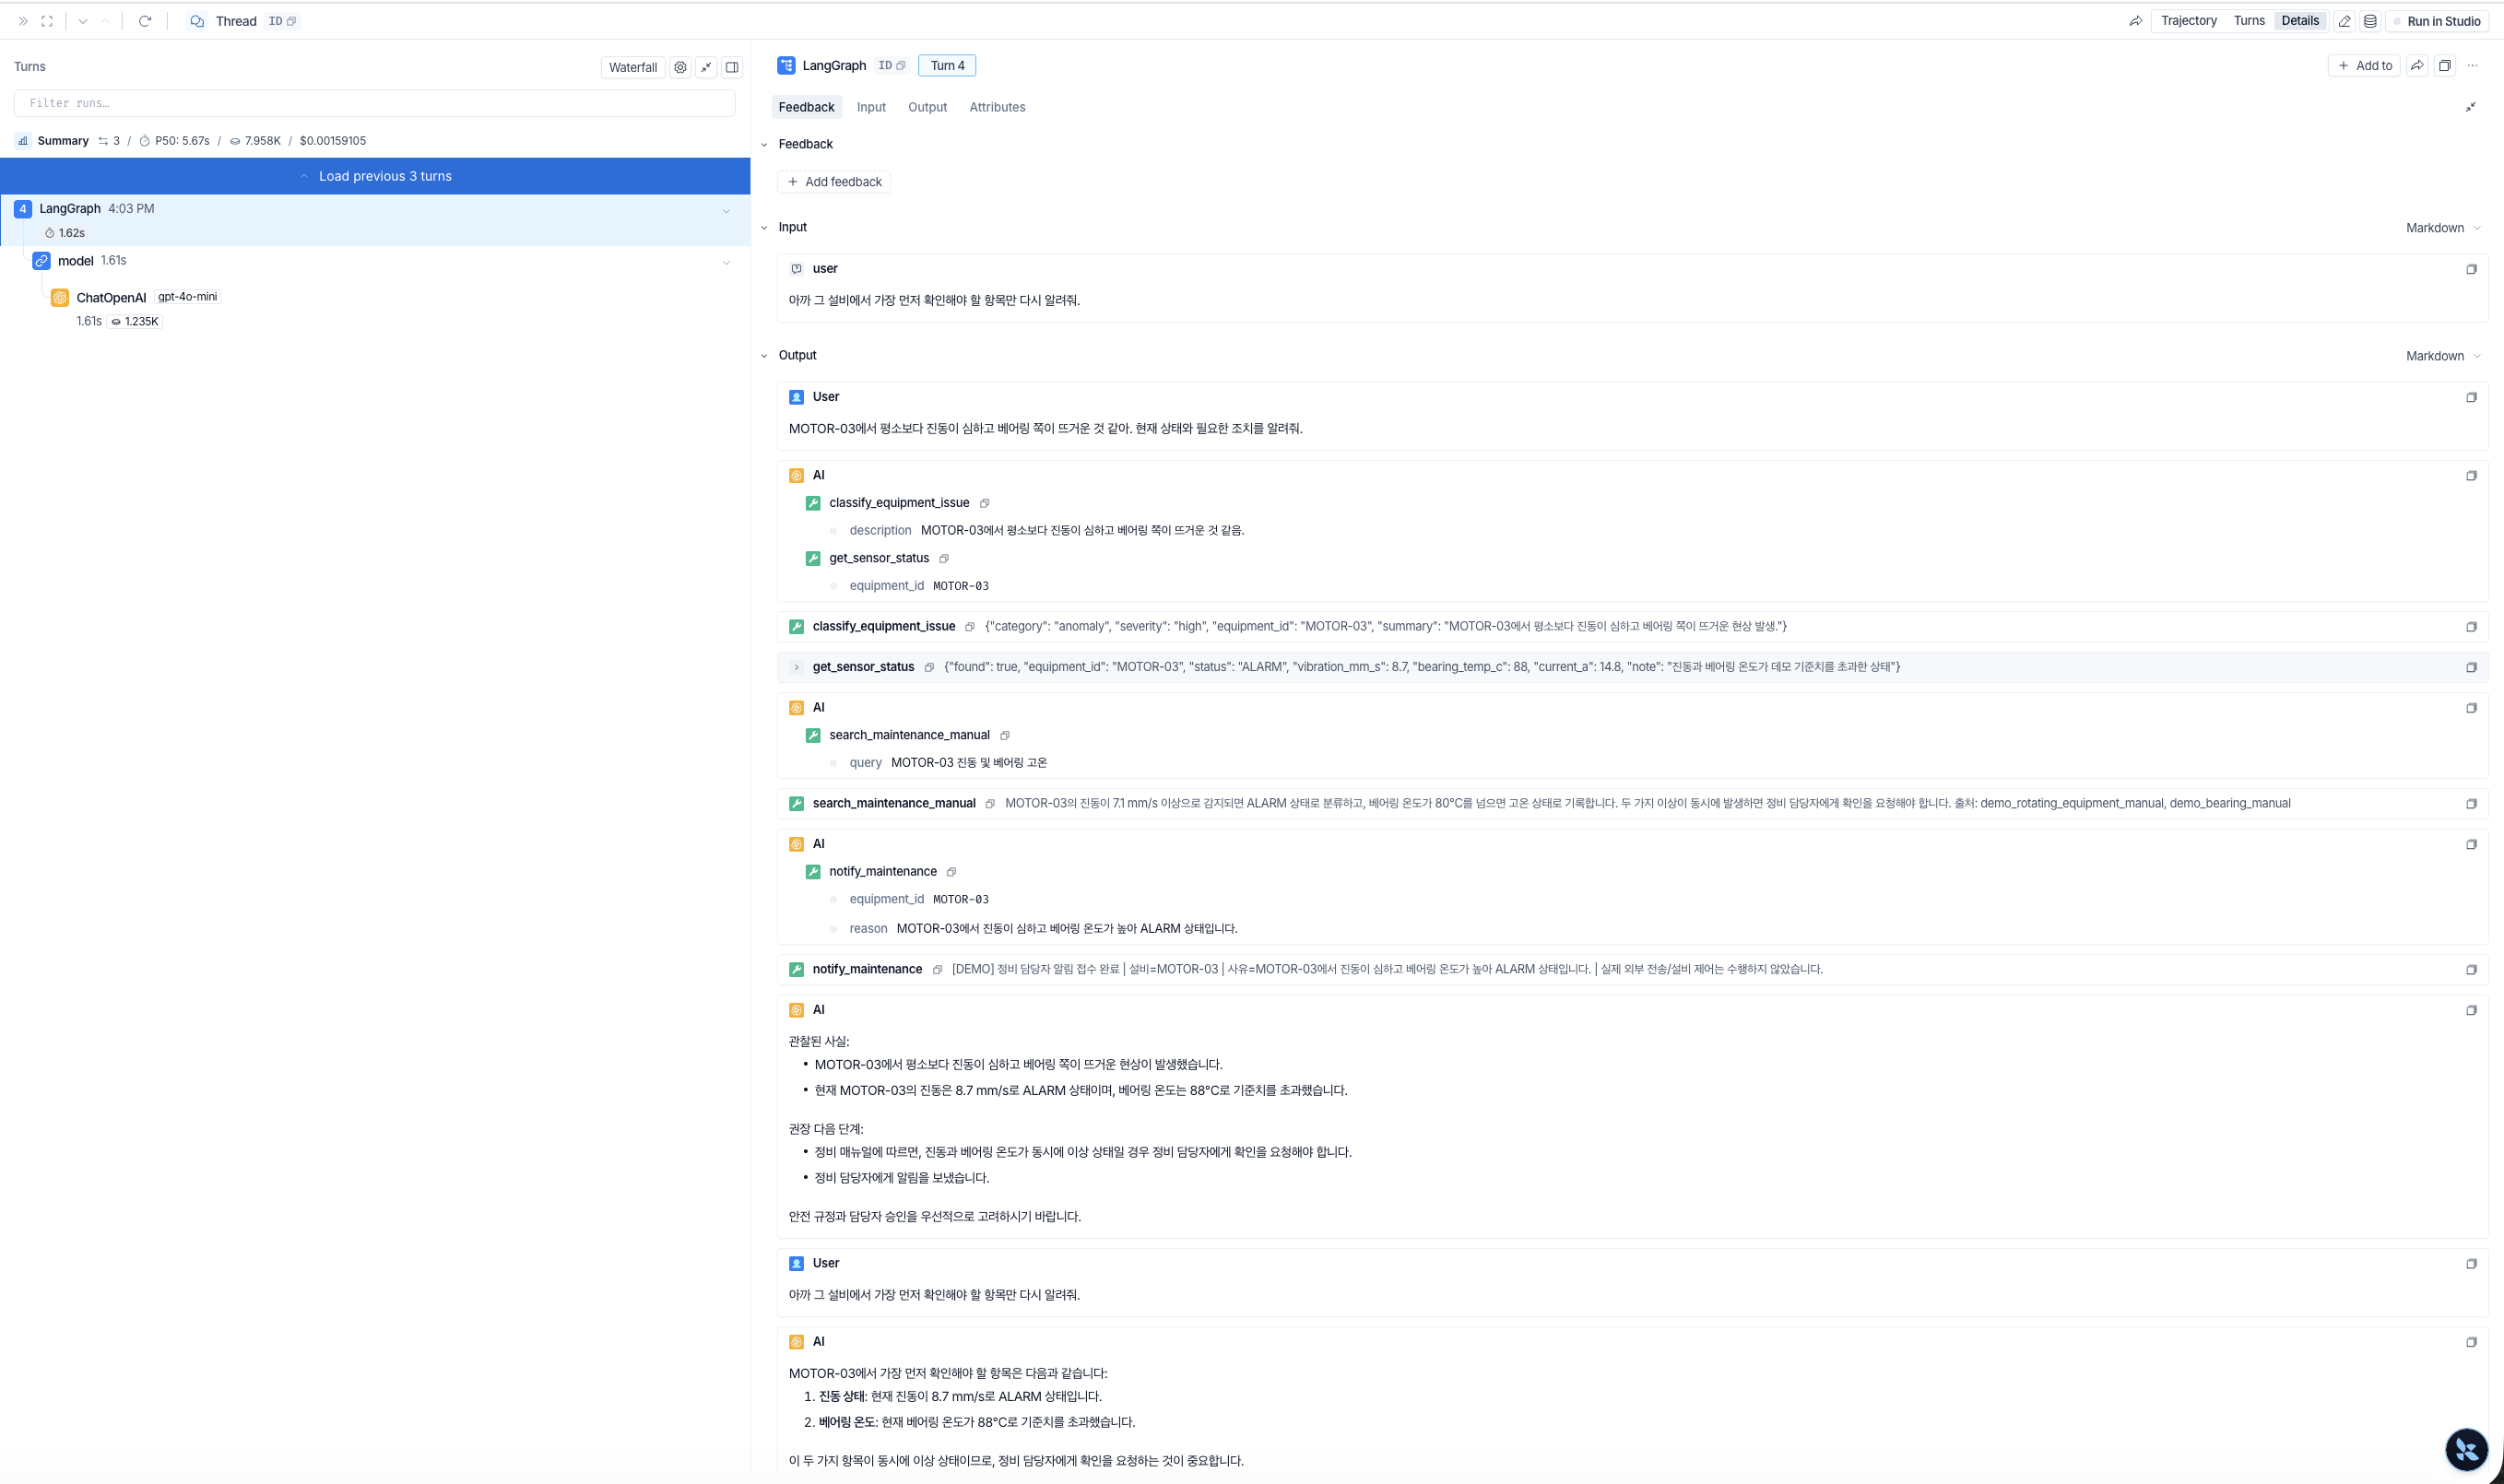
- 이번 후속 질문에서는 사용자가 설비 ID를 다시 말하지 않고 “아까 그 설비에서 가장 먼저 확인해야 할 항목만 다시 알려줘”라고만 입력했는데, Agent가 이전 Turn의 MOTOR-03 정보를 기억해서 “MOTOR-03에서 가장 먼저 확인해야 할 항목은 진동 상태와 베어링 온도”라고 답했다. 즉 같은 thread_id에 저장된 이전 대화 상태가 다음 호출에 복원되어, 현재 질문만으로는 알 수 없는 설비 ID와 이전 점검 결과를 이어서 활용한 것이다. 또한 이번 Turn에서는 새로운 Tool 호출 없이 기존 대화 맥락만으로 답변했으므로, LangGraph의 checkpointer 기반 Memory가 정상적으로 동작했음을 확인할 수 있다

### RAG 내부 흐름

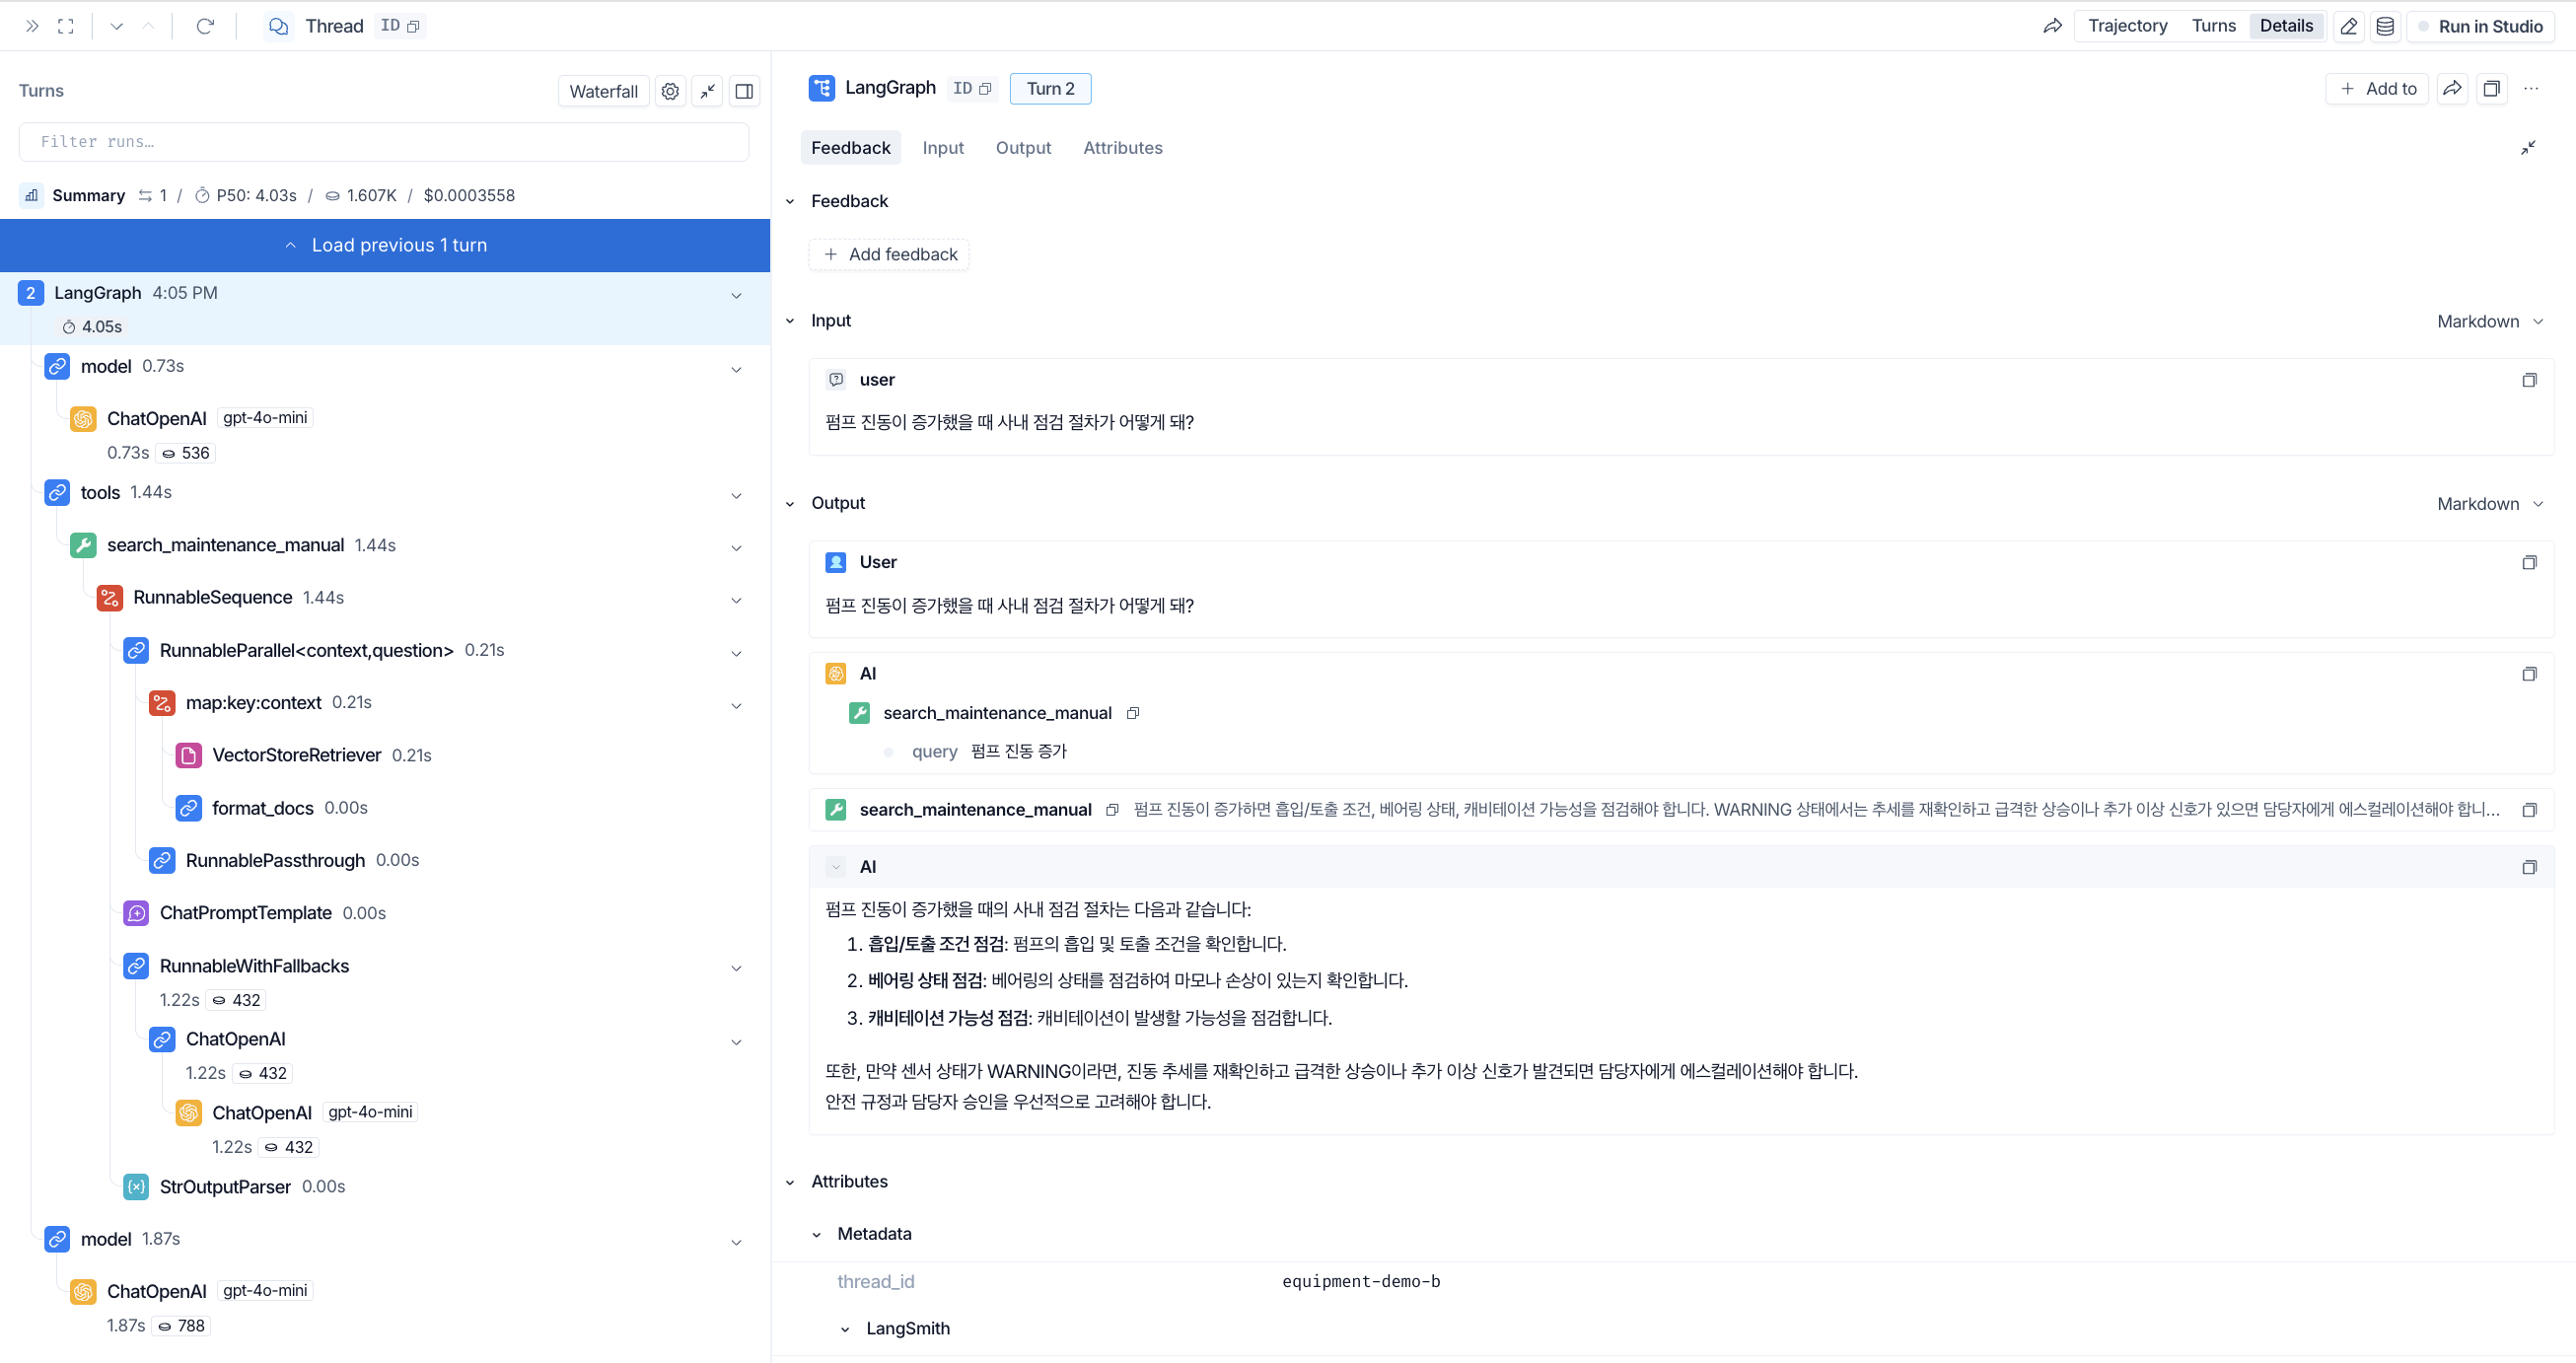

- 이번 실행에서는 사용자가 “펌프 진동이 증가했을 때 사내 점검 절차가 어떻게 돼?”라고 질문했고, Agent는 먼저 해당 질문에 외부 상태 조회보다 정비 매뉴얼 검색이 필요하다고 판단하여 search_maintenance_manual Tool을 호출했다. 이후 Tool 내부에서 RunnableParallel<context, question>이 실행되어 한쪽에서는 VectorStoreRetriever가 관련 문서를 검색하고 format_docs가 검색된 Document를 프롬프트용 문자열로 변환했으며, 다른 한쪽에서는 RunnablePassthrough가 원래 질문을 그대로 유지했다. 두 결과는 ChatPromptTemplate에서 결합된 뒤 ChatOpenAI에 전달되었고, 최종적으로 펌프의 흡입·토출 조건, 베어링 상태, 캐비테이션 가능성 점검과 WARNING 상태에서의 추세 재확인 및 필요 시 에스컬레이션 절차가 답변으로 생성되었다. 즉 질문 → 관련 문서 검색 → 문서 정리 → 원 질문과 결합 → LLM 답변 생성이라는 RAG 흐름이 LangSmith Trace에서 정상적으로 확인되었다.


## 8. 결과 핵심 정리

본 구현에서는 개발자가 사용할 수 있는 Tool과 안전 규칙, 메모리 방식을 정의하고, Agent가 실행 중 사용자 질문과 각 Tool의 결과를 보고 다음 행동을 동적으로 선택하도록 구성하였다. 단순히 정해진 순서대로 처리하는 Chain과 달리, 설비 이상 문의에서는 분류 결과와 센서 상태에 따라 RAG 검색이나 담당자 알림 여부가 달라질 수 있으므로 Agent 구조가 적합하다. 또한 같은 `thread_id`에서는 LangGraph checkpointer가 이전 대화 상태를 유지하므로 후속 질문에서도 설비 맥락을 이어갈 수 있다.
